In [17]:
import sys
import json
from itertools import combinations as iter_combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from statsmodels.tsa.stattools import acf as sm_acf
from statsmodels.graphics.tsaplots import plot_acf

sys.path.insert(0, str(Path(".").resolve()))
sys.path.insert(0, str(Path("scripts").resolve()))
from leaderboard_utils import extract_pollutant, display_dataset
from compute_local_leaderboard import _iter_model_series

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})

In [18]:
# ── Configuration ──────────────────────────────────────────────────────
RESULTS_ROOT = Path("output/results")
HORIZON      = "short"
THRESHOLD    = 50
MODELS       = ["seasonal_naive", "visiontspp_base", "patchtst"]
METRICS      = ["MASE"]
ALPHA        = 0.05
NLAGS        = 60   # ACF lags (covers ~2 months of daily data)

SEASONS = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall":   [9, 10, 11],
}
SEASON_ORDER = ["Winter", "Spring", "Summer", "Fall"]

_month_to_season = {m: s for s, months in SEASONS.items() for m in months}

def season_of(month: int) -> str:
    return _month_to_season[month]


def discover_datasets(results_root: Path, reference_model: str) -> list[str]:
    base = results_root / reference_model
    if not base.exists():
        return []
    datasets = []
    for ds_dir in sorted(base.iterdir()):
        if not ds_dir.is_dir():
            continue
        for freq_dir in sorted(ds_dir.iterdir()):
            if freq_dir.is_dir():
                datasets.append(f"{ds_dir.name}/{freq_dir.name}")
    return datasets


DATASETS = discover_datasets(RESULTS_ROOT, MODELS[0])
print(f"Discovered {len(DATASETS)} datasets: {DATASETS}")

Discovered 7 datasets: ['AURN/H', 'CNEMC_SMALL/H', 'CPCB/H', 'EEA_DE/H', 'EEA_FR/H', 'EPA/H', 'SINAICA/H']


In [19]:
# ── Pre-compute excluded sites (MASE or CRPS > THRESHOLD across all models) ───
print("Computing site exclusions...")
site_metric_values: dict[str, dict[tuple, list]] = {"MASE": {}, "CRPS": {}}

for model_name, dataset_id, horizon, item_ids, npz_metrics in _iter_model_series(RESULTS_ROOT):
    n_series = len(item_ids)
    for metric_name in ["MASE", "CRPS"]:
        arr = npz_metrics.get(metric_name)
        if arr is None or arr.shape[0] != n_series:
            continue
        reduce_axes = tuple(range(1, arr.ndim))
        per_series = np.nanmean(arr[:n_series], axis=reduce_axes) if reduce_axes else arr[:n_series]
        for i, iid in enumerate(item_ids):
            val = per_series[i]
            if not np.isnan(val):
                site_metric_values[metric_name].setdefault(
                    (dataset_id, horizon, iid), []
                ).append(float(val))

excluded_sites: dict[tuple, set] = {}
for key in set(site_metric_values["MASE"]) | set(site_metric_values["CRPS"]):
    dataset_id, horizon, iid = key
    mase_vals = site_metric_values["MASE"].get(key, [])
    crps_vals = site_metric_values["CRPS"].get(key, [])
    if (mase_vals and np.mean(mase_vals) > THRESHOLD) or \
       (crps_vals and np.mean(crps_vals) > THRESHOLD):
        excluded_sites.setdefault((dataset_id, horizon), set()).add(iid)

print(f"Threshold: mean MASE > {THRESHOLD} OR mean CRPS > {THRESHOLD} (across all models)")
if not excluded_sites:
    print("  No sites excluded.")
else:
    for (dataset_id, horizon), iids in sorted(excluded_sites.items()):
        pol_counts: dict[str, int] = {}
        for iid in iids:
            pol = extract_pollutant(iid)
            pol_counts[pol] = pol_counts.get(pol, 0) + 1
        breakdown = "  ".join(f"{pol}: {n}" for pol, n in sorted(pol_counts.items()))
        print(f"  {dataset_id}/{horizon}  —  {len(iids)} sites: {breakdown}")

Computing site exclusions...
Threshold: mean MASE > 50 OR mean CRPS > 50 (across all models)
  CPCB/H/short  —  1 sites: CO: 1
  EEA_DE/H/short  —  22 sites: NO2: 2  SO2: 20
  EPA/H/short  —  55 sites: CO: 2  SO2: 53


In [20]:
# ── Data loading helpers ────────────────────────────────────────────────

def load_model_data(results_root: Path, dataset_id: str, horizon: str, model: str):
    base         = results_root / model / dataset_id / horizon
    config_path  = base / "config.json"
    metrics_path = base / "metrics.npz"
    pred_path    = base / "predictions.npz"

    if not metrics_path.exists() or not config_path.exists():
        return None

    with open(config_path) as f:
        cfg = json.load(f)

    item_ids   = cfg["item_ids"]
    pollutants = [extract_pollutant(iid) for iid in item_ids]

    npz_m   = np.load(metrics_path)
    # Arrays are (n_series, n_windows, n_variates=1); squeeze the variate dim
    metrics = {k: npz_m[k][:, :, 0] for k in npz_m.files}  # (n_series, n_windows)

    timestamps = None
    if pred_path.exists():
        npz_p = np.load(pred_path)
        if "timestamps" in npz_p:
            timestamps = pd.to_datetime(npz_p["timestamps"][0, :, 0], unit="s")

    return dict(
        metrics=metrics,
        timestamps=timestamps,
        item_ids=item_ids,
        pollutants=pollutants,
        cfg=cfg,
    )


def load_all_models(results_root, dataset_id, horizon, models, metric):
    data = {}
    for model in models:
        d = load_model_data(results_root, dataset_id, horizon, model)
        if d is None or metric not in d["metrics"]:
            continue
        data[model] = d
    return data


def get_masked_mean(d, metric, pollutant, dataset_id, horizon, excluded_sites):
    """Return (n_windows,) mean across non-excluded sites for one pollutant/model."""
    pol_mask = np.array([p == pollutant for p in d["pollutants"]])
    if not pol_mask.any():
        return None
    arr = d["metrics"][metric][pol_mask].copy()
    exclude_ids = excluded_sites.get((dataset_id, horizon), set())
    pol_item_ids = [iid for iid, p in zip(d["item_ids"], d["pollutants"]) if p == pollutant]
    for i, iid in enumerate(pol_item_ids):
        if iid in exclude_ids:
            arr[i, :] = np.nan
    return np.nanmean(arr, axis=0)  # (n_windows,)

In [21]:
# ── Build tidy long-form DataFrame ─────────────────────────────────────────
# One row per (dataset × model × pollutant × window)
# Columns: dataset_id, model, pollutant, date, season, MASE

print("Building analysis DataFrame...")
records = []

for dataset_id in DATASETS:
    model_data = load_all_models(RESULTS_ROOT, dataset_id, HORIZON, MODELS, "MASE")
    if not model_data:
        print(f"  [skip] {dataset_id}")
        continue

    timestamps = next(
        (d["timestamps"] for d in model_data.values() if d["timestamps"] is not None),
        None,
    )
    if timestamps is None:
        print(f"  [skip] {dataset_id} — no timestamps")
        continue

    pollutants = sorted({pol for d in model_data.values() for pol in d["pollutants"]})

    for model, d in model_data.items():
        for pollutant in pollutants:
            mase_pw = get_masked_mean(d, "MASE", pollutant, dataset_id, HORIZON, excluded_sites)
            if mase_pw is None:
                continue

            for ts, mase_val in zip(timestamps, mase_pw):
                records.append({
                    "dataset_id": dataset_id,
                    "model":      model,
                    "pollutant":  pollutant,
                    "date":       ts,
                    "MASE":       float(mase_val),
                })

df = pd.DataFrame(records)
df["season"] = df["date"].dt.month.map(season_of)

print(f"DataFrame shape: {df.shape}")
print(f"Datasets: {df.dataset_id.unique().tolist()}")
print(f"Models:   {df.model.unique().tolist()}")
print(f"Pollutants: {sorted(df.pollutant.unique().tolist())}")
df.head()

Building analysis DataFrame...
DataFrame shape: (91224, 6)
Datasets: ['AURN/H', 'CNEMC_SMALL/H', 'CPCB/H', 'EEA_DE/H', 'EEA_FR/H', 'EPA/H', 'SINAICA/H']
Models:   ['seasonal_naive', 'visiontspp_base', 'patchtst']
Pollutants: ['CO', 'NO2', 'Ozone', 'PM10', 'PM2.5', 'SO2']


,dataset_id,model,pollutant,date,MASE,season
0,AURN/H,seasonal_naive,CO,2023-07-08,1.260394,Summer
1,AURN/H,seasonal_naive,CO,2023-07-09,1.751724,Summer
2,AURN/H,seasonal_naive,CO,2023-07-10,0.602459,Summer
3,AURN/H,seasonal_naive,CO,2023-07-11,0.283951,Summer
4,AURN/H,seasonal_naive,CO,2023-07-12,0.383795,Summer


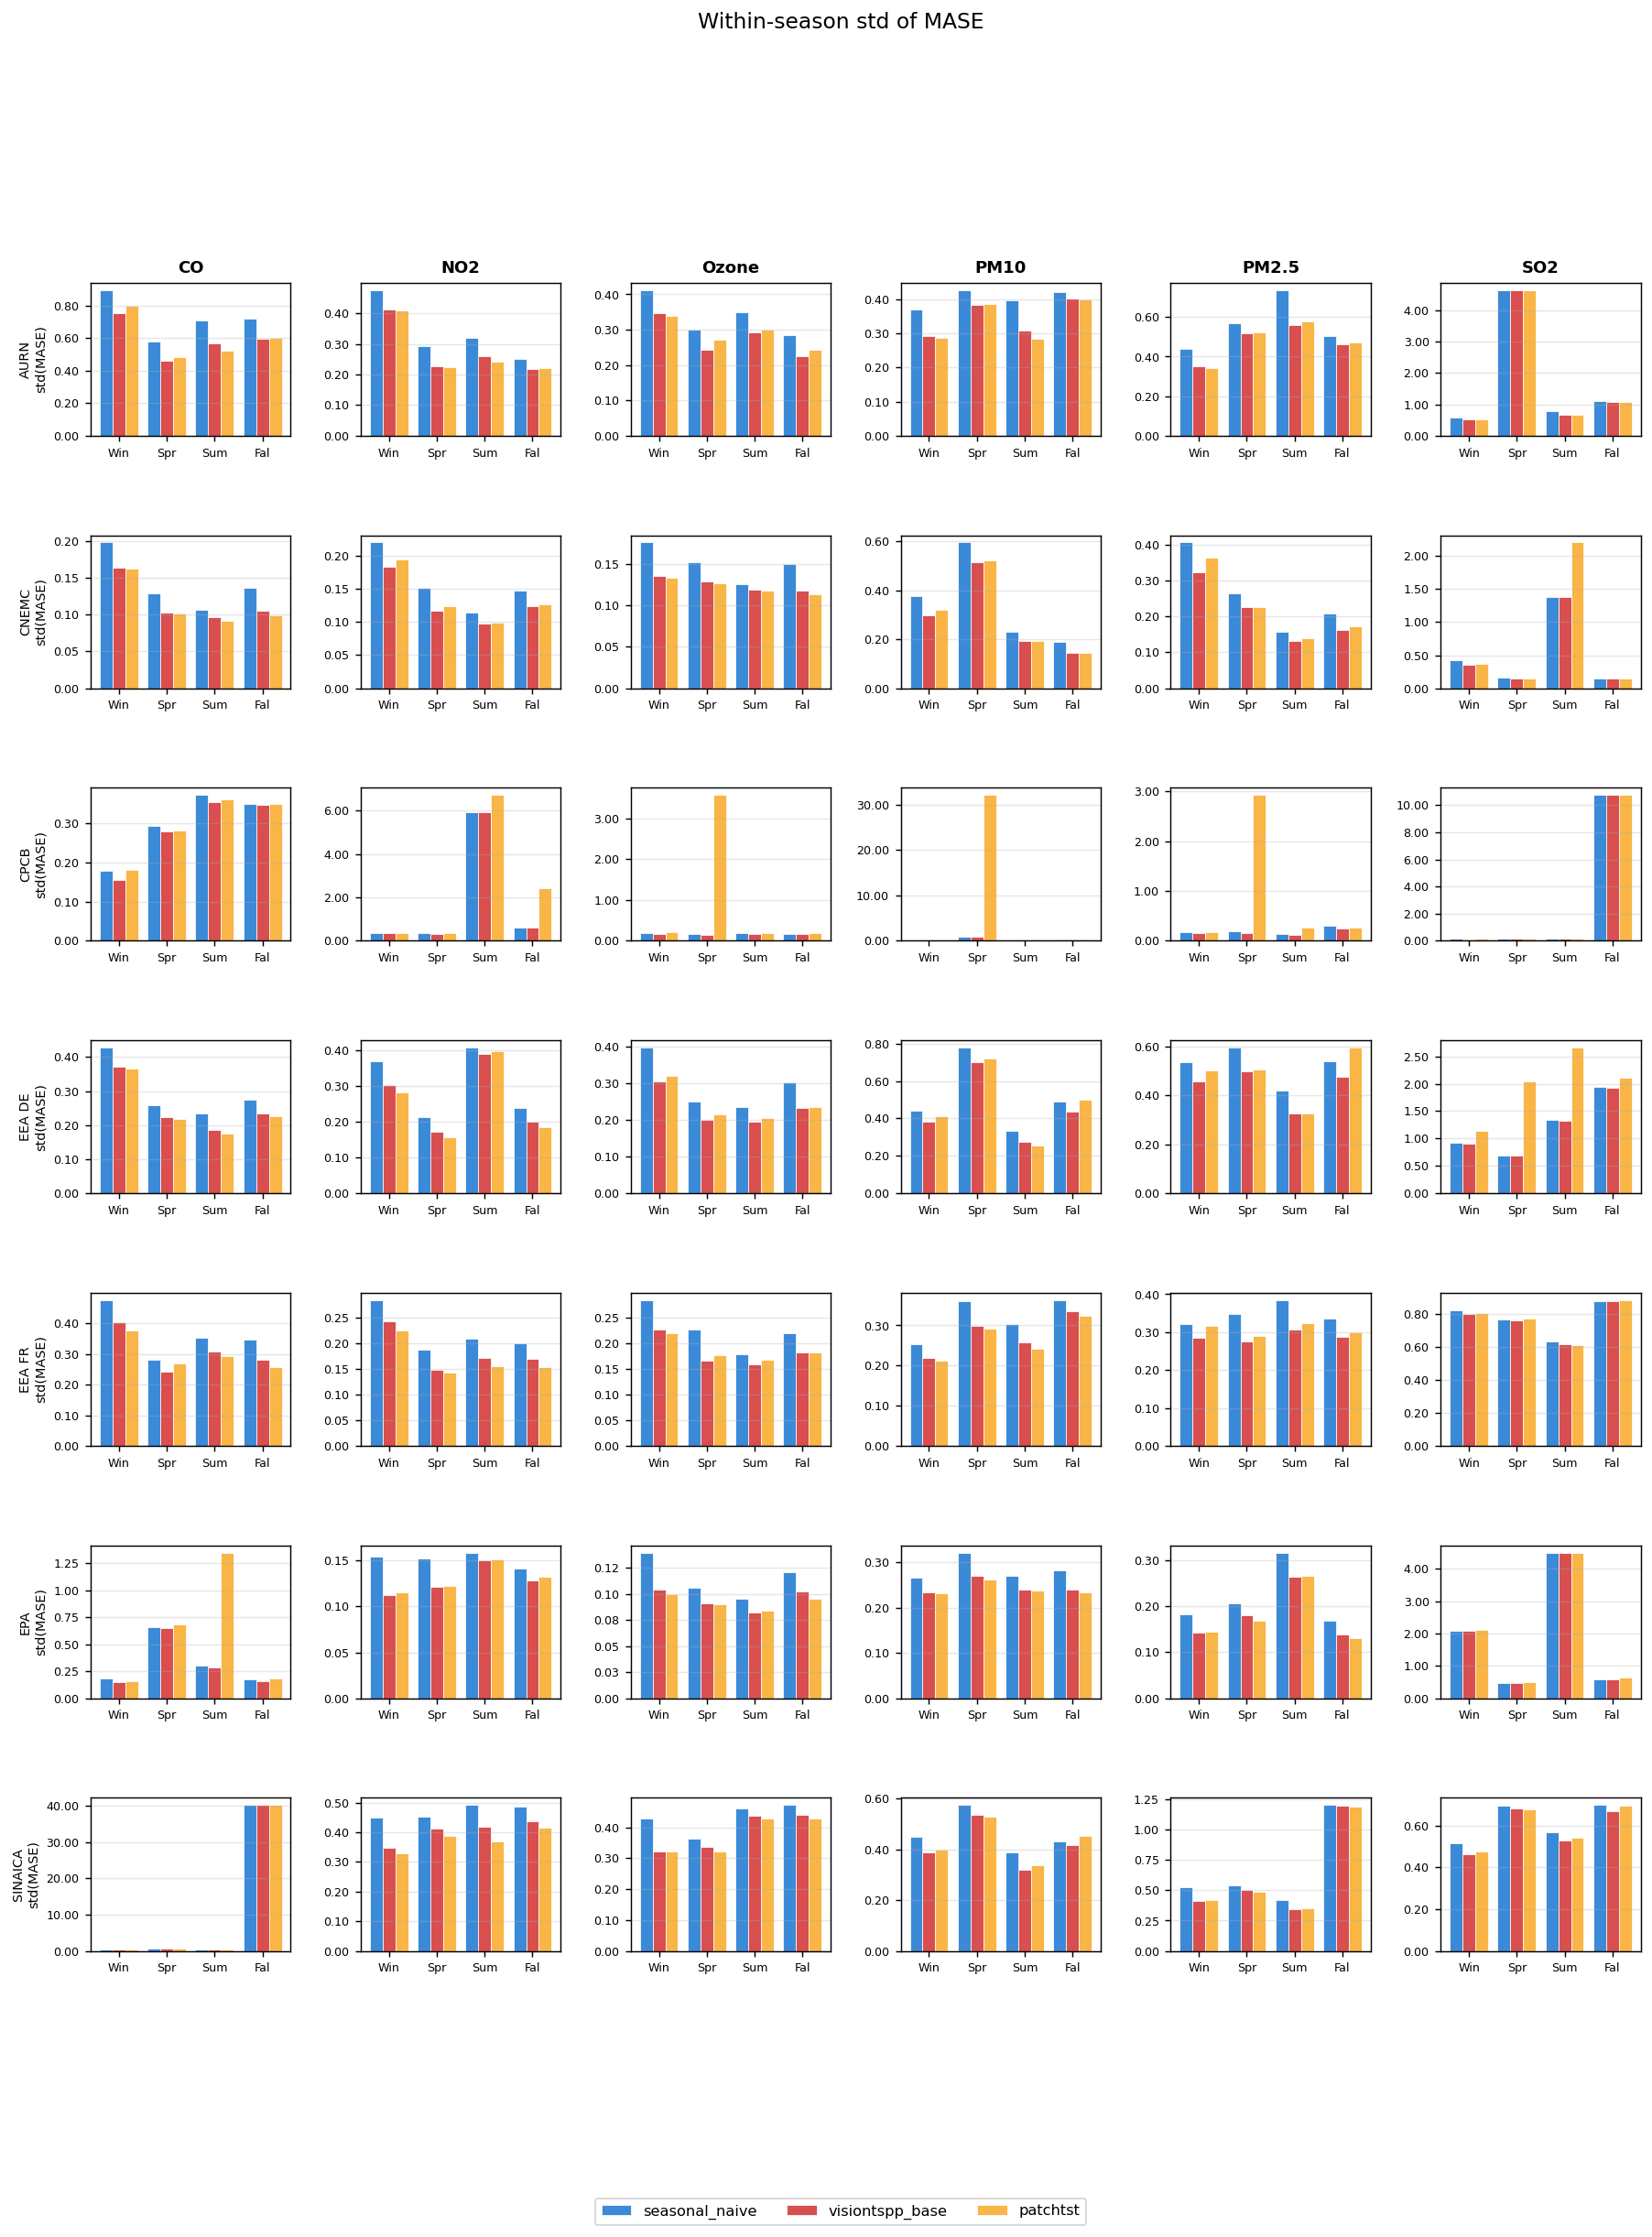

In [22]:
# ── Section 1: Seasonal Variance of MASE ──────────────────────────────────
# One combined figure: rows = datasets (stacked), cols = pollutants (side by side)
# Each pollutant has its own independent y-axis scale.

MODEL_COLORS = {"seasonal_naive": "#1976D2", "visiontspp_base": "#D32F2F", "patchtst": "#F9A825"}
SEASON_ABBR  = ["Win", "Spr", "Sum", "Fal"]

pollutants_all = sorted(df["pollutant"].unique())
n_pol = len(pollutants_all)
n_ds  = len(DATASETS)

fig, axes = plt.subplots(
    n_ds, n_pol,
    figsize=(2.8 * n_pol, 2.6 * n_ds),
    sharey=False,
    gridspec_kw={"hspace": 0.65, "wspace": 0.35},
)

for row, dataset_id in enumerate(DATASETS):
    sub = df[df["dataset_id"] == dataset_id]
    models_here = [m for m in MODELS if m in sub["model"].unique()]

    for col, pollutant in enumerate(pollutants_all):
        ax = axes[row, col]
        psub = sub[sub["pollutant"] == pollutant]

        if psub.empty:
            ax.set_visible(False)
            continue

        avail_models = [m for m in models_here if m in psub["model"].unique()]
        std_pivot = (
            psub.groupby(["season", "model"])["MASE"]
            .std()
            .unstack("model")
            .reindex(SEASON_ORDER)
            [avail_models]
        )

        x      = np.arange(len(SEASON_ORDER))
        width  = 0.8 / len(avail_models)
        offset = np.linspace(-0.4 + width / 2, 0.4 - width / 2, len(avail_models))

        for j, model in enumerate(avail_models):
            vals = std_pivot[model].values
            ax.bar(
                x + offset[j], vals, width,
                label=model, color=MODEL_COLORS.get(model, f"C{j}"),
                alpha=0.85, edgecolor="white", linewidth=0.5,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(SEASON_ABBR, fontsize=7)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="y", labelsize=7)

        if row == 0:
            ax.set_title(pollutant, fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(display_dataset(dataset_id) + "\nstd(MASE)", fontsize=8)

# Shared legend below the figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(MODELS),
           fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Within-season std of MASE", fontsize=13, y=1.005)
plt.show()

In [23]:
# ── Section 2: Kruskal-Wallis Tests + Pairwise Post-hoc ───────────────────
# H0: the distribution of daily errors is the same across all 4 seasons.
# If significant (p < ALPHA): pairwise Mann-Whitney U + Bonferroni correction.

N_PAIRS         = 6        # C(4,2) season pairs
ALPHA_BONF      = ALPHA / N_PAIRS
SEASON_PAIRS    = list(iter_combinations(SEASON_ORDER, 2))

kw_records = []

for dataset_id in DATASETS:
    sub = df[df["dataset_id"] == dataset_id]
    if sub.empty:
        continue

    for model in MODELS:
        msub = sub[sub["model"] == model]
        if msub.empty:
            continue

        for pollutant in sorted(msub["pollutant"].unique()):
            psub = msub[msub["pollutant"] == pollutant]

            for metric in METRICS:
                groups = [
                    psub.loc[psub["season"] == s, metric].dropna().values
                    for s in SEASON_ORDER
                ]
                # Skip if any season has fewer than 3 observations
                if any(len(g) < 3 for g in groups):
                    continue

                H, p = stats.kruskal(*groups)
                rec = {
                    "dataset_id": dataset_id,
                    "model":      model,
                    "pollutant":  pollutant,
                    "metric":     metric,
                    "H":          round(H, 3),
                    "p_kw":       p,
                    "significant": p < ALPHA,
                }

                # Pairwise post-hoc (only if K-W significant)
                if p < ALPHA:
                    for (s1, s2) in SEASON_PAIRS:
                        g1 = psub.loc[psub["season"] == s1, metric].dropna().values
                        g2 = psub.loc[psub["season"] == s2, metric].dropna().values
                        if len(g1) < 3 or len(g2) < 3:
                            continue
                        _, p_mw = stats.mannwhitneyu(g1, g2, alternative="two-sided")
                        p_adj = min(p_mw * N_PAIRS, 1.0)   # Bonferroni
                        rec[f"p_{s1}_vs_{s2}"] = round(p_adj, 4)

                kw_records.append(rec)

kw_df = pd.DataFrame(kw_records)
print(f"Kruskal-Wallis results: {len(kw_df)} tests")
print(f"Significant (p < {ALPHA}): {kw_df['significant'].sum()} / {len(kw_df)}")
kw_df.head(10)

Kruskal-Wallis results: 126 tests
Significant (p < 0.05): 47 / 126


,dataset_id,model,pollutant,metric,H,p_kw,significant,p_Winter_vs_Spring,p_Winter_vs_Summer,p_Winter_vs_Fall,p_Spring_vs_Summer,p_Spring_vs_Fall,p_Summer_vs_Fall
0,AURN/H,seasonal_naive,CO,MASE,3.328,0.343785,False,NaN,NaN,NaN,NaN,NaN,NaN
1,AURN/H,seasonal_naive,NO2,MASE,4.185,0.242218,False,NaN,NaN,NaN,NaN,NaN,NaN
2,AURN/H,seasonal_naive,Ozone,MASE,2.020,0.568348,False,NaN,NaN,NaN,NaN,NaN,NaN
3,AURN/H,seasonal_naive,PM10,MASE,0.747,0.862002,False,NaN,NaN,NaN,NaN,NaN,NaN
4,AURN/H,seasonal_naive,PM2.5,MASE,1.401,0.705261,False,NaN,NaN,NaN,NaN,NaN,NaN
5,AURN/H,seasonal_naive,SO2,MASE,1.373,0.711984,False,NaN,NaN,NaN,NaN,NaN,NaN
6,AURN/H,visiontspp_base,CO,MASE,3.940,0.267985,False,NaN,NaN,NaN,NaN,NaN,NaN
7,AURN/H,visiontspp_base,NO2,MASE,4.374,0.223807,False,NaN,NaN,NaN,NaN,NaN,NaN
8,AURN/H,visiontspp_base,Ozone,MASE,5.740,0.124975,False,NaN,NaN,NaN,NaN,NaN,NaN
9,AURN/H,visiontspp_base,PM10,MASE,0.423,0.935465,False,NaN,NaN,NaN,NaN,NaN,NaN


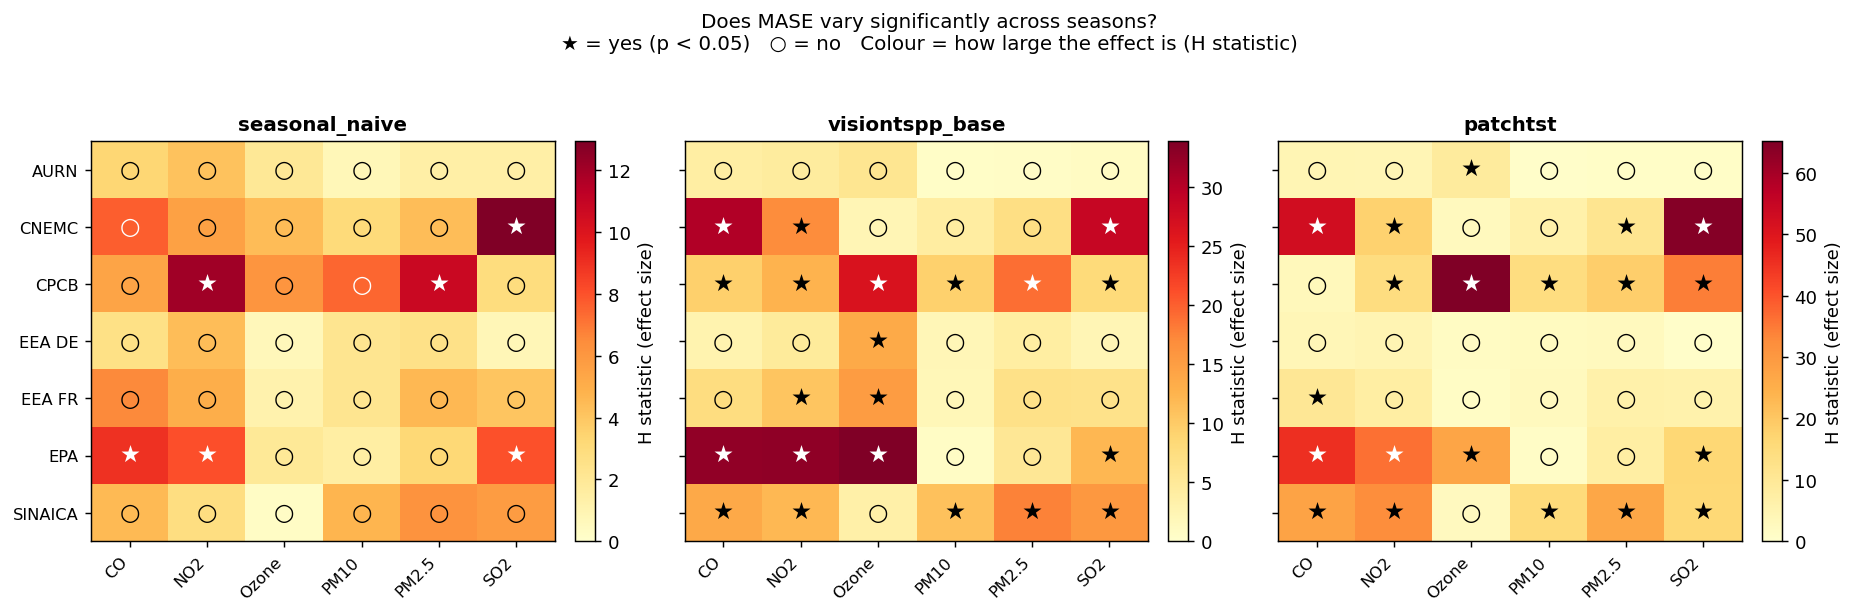

─────────────────────────────────────────────────────────────────
Where a seasonal effect was found, which seasons differ?
(Bonferroni-corrected pairwise tests, only significant pairs shown)
─────────────────────────────────────────────────────────────────

AURN
  Ozone:
    [patchtst]  none

CNEMC
  CO:
    [visiontspp_base]  Winter vs Summer,  Spring vs Summer,  Spring vs Fall
    [patchtst]  Winter vs Summer,  Winter vs Fall,  Spring vs Summer,  Spring vs Fall,  Summer vs Fall
  NO2:
    [visiontspp_base]  Spring vs Summer,  Spring vs Fall
    [patchtst]  Spring vs Summer,  Spring vs Fall
  PM2.5:
    [patchtst]  Spring vs Fall
  SO2:
    [seasonal_naive]  Winter vs Summer,  Spring vs Summer
    [visiontspp_base]  Winter vs Summer,  Winter vs Fall,  Spring vs Summer,  Spring vs Fall
    [patchtst]  Winter vs Summer,  Winter vs Fall,  Spring vs Summer,  Spring vs Fall,  Summer vs Fall

CPCB
  CO:
    [visiontspp_base]  Winter vs Fall
  NO2:
    [seasonal_naive]  Winter vs Fall
    [v

In [24]:
# ── K-W Results: Interpretable Summary ─────────────────────────────────────
# Question: does MASE differ significantly across the four seasons?
# Colour = H-statistic (effect size). ★ = yes, ○ = no seasonal effect.

mase_kw          = kw_df[kw_df["metric"] == "MASE"].copy()
pollutants_order = sorted(mase_kw["pollutant"].unique())
datasets_labels  = [display_dataset(d) for d in DATASETS]
pair_cols        = [c for c in mase_kw.columns if c.startswith("p_") and "_vs_" in c]

# ── Heatmap ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(MODELS), figsize=(4.8 * len(MODELS), 4.5), sharey=True)

for ax, model in zip(np.atleast_1d(axes), MODELS):
    mdf    = mase_kw[mase_kw["model"] == model]
    H_mat  = np.full((len(DATASETS), len(pollutants_order)), np.nan)
    sig_mat = np.zeros_like(H_mat, dtype=bool)

    for _, row in mdf.iterrows():
        i = DATASETS.index(row["dataset_id"])
        j = pollutants_order.index(row["pollutant"])
        H_mat[i, j]   = row["H"]
        sig_mat[i, j] = bool(row["significant"])

    vmax = np.nanmax(H_mat) if not np.all(np.isnan(H_mat)) else 1
    im   = ax.imshow(H_mat, cmap="YlOrRd", aspect="auto", vmin=0, vmax=vmax)

    ax.set_xticks(range(len(pollutants_order)))
    ax.set_xticklabels(pollutants_order, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(DATASETS)))
    ax.set_yticklabels(datasets_labels, fontsize=9)
    ax.set_title(model, fontsize=11, fontweight="bold")

    for i in range(len(DATASETS)):
        for j in range(len(pollutants_order)):
            if np.isnan(H_mat[i, j]):
                continue
            mark  = "★" if sig_mat[i, j] else "○"
            shade = H_mat[i, j] / vmax
            color = "white" if shade > 0.55 else "black"
            ax.text(j, i, mark, ha="center", va="center", fontsize=13, color=color)

    plt.colorbar(im, ax=ax, label="H statistic (effect size)", fraction=0.046, pad=0.04)

fig.suptitle(
    "Does MASE vary significantly across seasons?\n"
    "★ = yes (p < 0.05)   ○ = no   Colour = how large the effect is (H statistic)",
    fontsize=11, y=1.04,
)
plt.tight_layout()
plt.show()

# ── Plain-language pairwise summary ─────────────────────────────────────────
print("─" * 65)
print("Where a seasonal effect was found, which seasons differ?")
print("(Bonferroni-corrected pairwise tests, only significant pairs shown)")
print("─" * 65)

for dataset_id in DATASETS:
    ds_rows = mase_kw[(mase_kw["dataset_id"] == dataset_id) & mase_kw["significant"]]
    if ds_rows.empty:
        continue
    print(f"\n{display_dataset(dataset_id)}")

    for pollutant in pollutants_order:
        pol_rows = ds_rows[ds_rows["pollutant"] == pollutant]
        if pol_rows.empty:
            continue
        print(f"  {pollutant}:")
        for _, row in pol_rows.iterrows():
            sig_pairs = [
                col.replace("p_", "").replace("_vs_", " vs ")
                for col in pair_cols
                if col in row and not pd.isna(row[col]) and row[col] < ALPHA
            ]
            pairs_str = ",  ".join(sig_pairs) if sig_pairs else "none"
            print(f"    [{row['model']}]  {pairs_str}")

print()